<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/AnomalyIsolutionForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anomaly Detection: Isolation Forest Algorithm

---


**Isolation Forest** is an unsupervised machine learning algorithm designed specifically for anomaly detection. Unlike traditional methods that attempt to profile "normal" data points and flag deviations, Isolation Forest explicitly identifies anomalies by **isolating** them from the rest of the dataset.

It is highly efficient and uniquely suited for high-dimensional datasets where density-based or distance-based algorithms struggle.


## The Core Concept: Why Isolation?

The algorithm relies on two fundamental properties of anomalous data points:
1. **Few in Number:** Anomalies are rare compared to normal data instances.
2. **Distinct Attributes:** They possess feature values that are significantly different from normal instances.

Because of these properties, anomalies are much easier to isolate. If you randomly partition the data space using a tree structure, anomalies will end up isolated in branches **much closer to the root of the tree**, while normal points require many more splits to isolate.


## How It Works Step-by-Step

Isolation Forest builds an ensemble of **Isolation Trees (iTrees)** (similar to a Random Forest, but built for isolation instead of classification):

* **Step 1: Subsampling:** A random subset of the dataset is chosen to construct an individual iTree.
* **Step 2: Recursive Splitting:**
    * A feature $q$ is selected completely at random from the dataset features.
    * A split value $p$ is selected completely at random between the minimum and maximum values of feature $q$.
* **Step 3: Branching:** The data space is divided into two halves based on the condition $x_i[q] < p$.
* **Step 4: Tree Termination:** This random partitioning repeats recursively until either:
    * The tree reaches a maximum height limit.
    * All data points are fully isolated into individual leaf nodes ($|S| = 1$).
    * All remaining data points have identical values.
* **Step 5: Forest Evaluation:** Steps 1–4 are repeated hundreds of times to build a forest of independent iTrees.

## Mathematical Formulation: Calculating Anomaly Scores

To determine if a point is an anomaly, the algorithm measures its **path length** across all trees in the forest.

### 1. Path Length $h(x)$
Let $h(x)$ be the path length of a data point $x$ in a specific iTree, measured by the number of edges $x$ traverses from the root node to a terminating leaf node.

### 2. Average Path Length of Unsuccessful Searches $c(n)$
Since iTrees have an equivalent structure to a Binary Search Tree (BST), the average path length for a dataset size of $n$ instances can be mathematically normalized using the standard BST formula:

$$c(n) = 2\ln(n - 1) + 0.5772156649 - \frac{2(n - 1)}{n}$$

*Where $0.5772156649$ is Euler's constant.*

### 3. The Anomaly Score Formula $s(x, n)$
The anomaly score $s$ for a data point $x$ over a collection of trees is calculated by normalizing its mean path length $E(h(x))$ against the average expected path length $c(n)$:

$$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$

### Interpreting the Anomaly Score Bounds
The value of $s(x, n)$ is strictly bounded between **$0$** and **$1$**:

* **Score $\approx 1$ (Definite Anomaly):** If $E(h(x)) \to 0$, the exponent approaches $0$, meaning $s \to 1$. The point isolates very close to the root node across the forest.
* **Score $\ll 0.5$ (Normal Data Point):** If $E(h(x)) \to n$, the path length is very deep, meaning $s \to 0$. The point requires many splits to isolate, signaling it sits in a dense cluster of normal data.
* **Score $\approx 0.5$ (Structurally Indeterminate):** If the entire population returns an average score around $0.5$, the dataset generally does not contain distinct, easily isolatable anomalies.

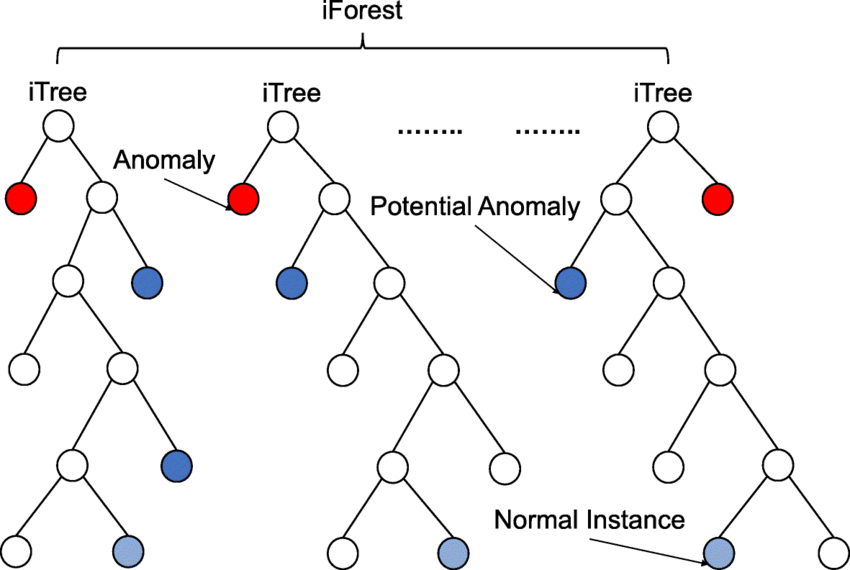

## Pros and Cons of Isolation Forest

### Advantages
* **Linear Time Complexity:** It operates with a low time complexity of $O(t \cdot \psi \log \psi)$, where $t$ is the number of trees and $\psi$ is the subsampling size. It is incredibly fast and memory-efficient.
* **No Distance Computations:** It avoids expensive pair-wise distance or density metrics, completely bypassing the Curse of Dimensionality.
* **Swamping and Masking Protection:** Because it uses localized subsampling partitions instead of the whole dataset at once, it cleanly identifies anomalies even when they clump together (masking) or sit near normal zones (swamping).

### Disadvantages
* **Artifact Visualizations:** Because splits are strictly axis-parallel (vertical and horizontal lines), it can sometimes produce ghost anomaly zones in empty spaces where no data points actually exist.
* **Hyperparameter Selection:** You must tune the **contamination rate** (the expected proportion of anomalies in the dataset) to draw the final binary threshold line between normal data and outliers.




# ***Impelement Annomaly Isolation Foreset tree***

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
df=pd.read_csv("/content/healthcare_dataset.csv",nrows=400)

In [38]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                400 non-null    object 
 1   Age                 400 non-null    int64  
 2   Gender              400 non-null    object 
 3   Blood Type          400 non-null    object 
 4   Medical Condition   400 non-null    object 
 5   Date of Admission   400 non-null    object 
 6   Doctor              400 non-null    object 
 7   Hospital            400 non-null    object 
 8   Insurance Provider  400 non-null    object 
 9   Billing Amount      400 non-null    float64
 10  Room Number         400 non-null    int64  
 11  Admission Type      400 non-null    object 
 12  Discharge Date      400 non-null    object 
 13  Medication          400 non-null    object 
 14  Test Results        400 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 47.0+ K

In [40]:
print('\nUnique values per column:')
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Unique values per column:
Name: 400 unique values
Age: 68 unique values
Gender: 2 unique values
Blood Type: 8 unique values
Medical Condition: 6 unique values
Date of Admission: 358 unique values
Doctor: 398 unique values
Hospital: 399 unique values
Insurance Provider: 5 unique values
Billing Amount: 400 unique values
Room Number: 252 unique values
Admission Type: 3 unique values
Discharge Date: 345 unique values
Medication: 5 unique values
Test Results: 3 unique values


In [41]:
# Drop irrelevant columns
df_processed = df.drop(columns=['Name', 'Doctor', 'Hospital'])

# Convert date columns to datetime objects
df_processed['Date of Admission'] = pd.to_datetime(df_processed['Date of Admission'])
df_processed['Discharge Date'] = pd.to_datetime(df_processed['Discharge Date'])

# Calculate admission duration in days
df_processed['Admission Duration'] = (df_processed['Discharge Date'] - df_processed['Date of Admission']).dt.days

# Extract month and day of week from admission date
df_processed['Admission Month'] = df_processed['Date of Admission'].dt.month
df_processed['Admission DayOfWeek'] = df_processed['Date of Admission'].dt.dayofweek

df_processed.head()

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Admission Duration,Admission Month,Admission DayOfWeek
0,30,Male,B-,Cancer,2024-01-31,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,1,2
1,62,Male,A+,Obesity,2019-08-20,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,8,1
2,76,Female,A-,Obesity,2022-09-22,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,9,3
3,28,Female,O+,Diabetes,2020-11-18,Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,11,2
4,43,Female,AB+,Cancer,2022-09-19,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20,9,0


In [42]:
# Identify categorical columns for one-hot encoding
categorical_cols = [
    'Gender',
    'Blood Type',
    'Medical Condition',
    'Insurance Provider',
    'Admission Type',
    'Medication',
    'Test Results'
]

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Display the first few rows and info of the encoded DataFrame
print('DataFrame after one-hot encoding:')
df_encoded.head()

DataFrame after one-hot encoding:


,Age,Date of Admission,Billing Amount,Room Number,Discharge Date,Admission Duration,Admission Month,Admission DayOfWeek,Gender_Male,Blood Type_A-,...,Insurance Provider_Medicare,Insurance Provider_UnitedHealthcare,Admission Type_Emergency,Admission Type_Urgent,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin,Test Results_Inconclusive,Test Results_Normal
0,30,2024-01-31,18856.281306,328,2024-02-02,2,1,2,True,False,...,False,False,False,True,False,False,True,False,False,True
1,62,2019-08-20,33643.327287,265,2019-08-26,6,8,1,True,False,...,True,False,True,False,True,False,False,False,True,False
2,76,2022-09-22,27955.096079,205,2022-10-07,15,9,3,False,True,...,False,False,True,False,False,False,False,False,False,True
3,28,2020-11-18,37909.782410,450,2020-12-18,30,11,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,43,2022-09-19,14238.317814,458,2022-10-09,20,9,0,False,False,...,False,False,False,True,False,False,False,True,False,False


In [43]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 33 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Age                                  400 non-null    int64         
 1   Date of Admission                    400 non-null    datetime64[ns]
 2   Billing Amount                       400 non-null    float64       
 3   Room Number                          400 non-null    int64         
 4   Discharge Date                       400 non-null    datetime64[ns]
 5   Admission Duration                   400 non-null    int64         
 6   Admission Month                      400 non-null    int32         
 7   Admission DayOfWeek                  400 non-null    int32         
 8   Gender_Male                          400 non-null    bool          
 9   Blood Type_A-                        400 non-null    bool          
 10  Blood Type_AB+

In [44]:
# Drop the original date columns as their information has been extracted
df_final = df_encoded.drop(columns=['Date of Admission', 'Discharge Date'])

print('DataFrame after dropping original date columns:')
df_final.head()

DataFrame after dropping original date columns:


,Age,Billing Amount,Room Number,Admission Duration,Admission Month,Admission DayOfWeek,Gender_Male,Blood Type_A-,Blood Type_AB+,Blood Type_AB-,...,Insurance Provider_Medicare,Insurance Provider_UnitedHealthcare,Admission Type_Emergency,Admission Type_Urgent,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin,Test Results_Inconclusive,Test Results_Normal
0,30,18856.281306,328,2,1,2,True,False,False,False,...,False,False,False,True,False,False,True,False,False,True
1,62,33643.327287,265,6,8,1,True,False,False,False,...,True,False,True,False,True,False,False,False,True,False
2,76,27955.096079,205,15,9,3,False,True,False,False,...,False,False,True,False,False,False,False,False,False,True
3,28,37909.782410,450,30,11,2,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False
4,43,14238.317814,458,20,9,0,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False


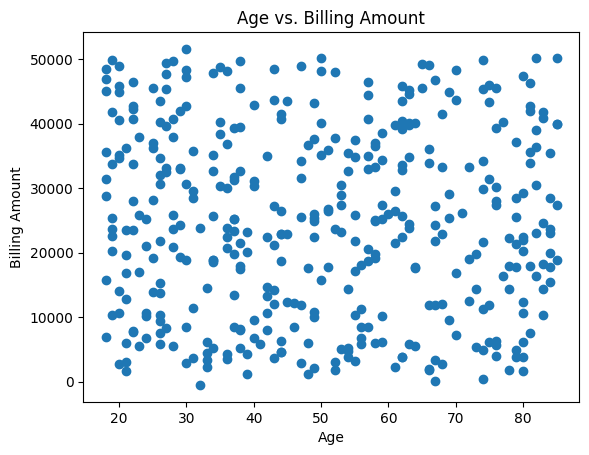

In [45]:
plt.scatter(df_final['Age'], df_final['Billing Amount'])
plt.xlabel('Age')
plt.ylabel('Billing Amount')
plt.title('Age vs. Billing Amount')
plt.show()

In [46]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Age                                  400 non-null    int64  
 1   Billing Amount                       400 non-null    float64
 2   Room Number                          400 non-null    int64  
 3   Admission Duration                   400 non-null    int64  
 4   Admission Month                      400 non-null    int32  
 5   Admission DayOfWeek                  400 non-null    int32  
 6   Gender_Male                          400 non-null    bool   
 7   Blood Type_A-                        400 non-null    bool   
 8   Blood Type_AB+                       400 non-null    bool   
 9   Blood Type_AB-                       400 non-null    bool   
 10  Blood Type_B+                        400 non-null    bool   
 11  Blood Type_B-                   

In [53]:
from sklearn.ensemble import IsolationForest

# Initialize the Isolation Forest model
# n_estimators: The number of base estimators (trees) in the ensemble.
# contamination: The proportion of outliers in the dataset. This is an important parameter, as it helps define the decision boundary.
# random_state: For reproducibility of results.
model = IsolationForest(n_estimators=100, contamination=0.2, random_state=42)
# Fit the model to the data
model.fit(df_final)
prediction=model.predict(df_final)
prediction

array([-1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,
       -1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1, -1, -1,  1,  1,  1,  1, -1, -1, -1, -1,  1,  1, -1, -1,
       -1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,
        1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1,  1, -1, -1, -1,  1, -1,
       -1,  1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1, -1,  1,  1, -1,  1,
        1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1

In [54]:
index=np.where(prediction<1)
index

(array([  0,   6,  10,  11,  17,  24,  28,  34,  38,  40,  45,  50,  55,
         65,  67,  68,  72,  77, 120, 122, 123, 128, 129, 130, 131, 134,
        135, 136, 141, 142, 150, 163, 165, 172, 174, 179, 180, 182, 183,
        184, 186, 187, 191, 195, 196, 197, 199, 202, 205, 209, 216, 221,
        230, 231, 232, 246, 250, 261, 274, 276, 279, 281, 292, 296, 307,
        319, 322, 323, 329, 332, 341, 353, 354, 365, 368, 373, 377, 383,
        392, 396]),)

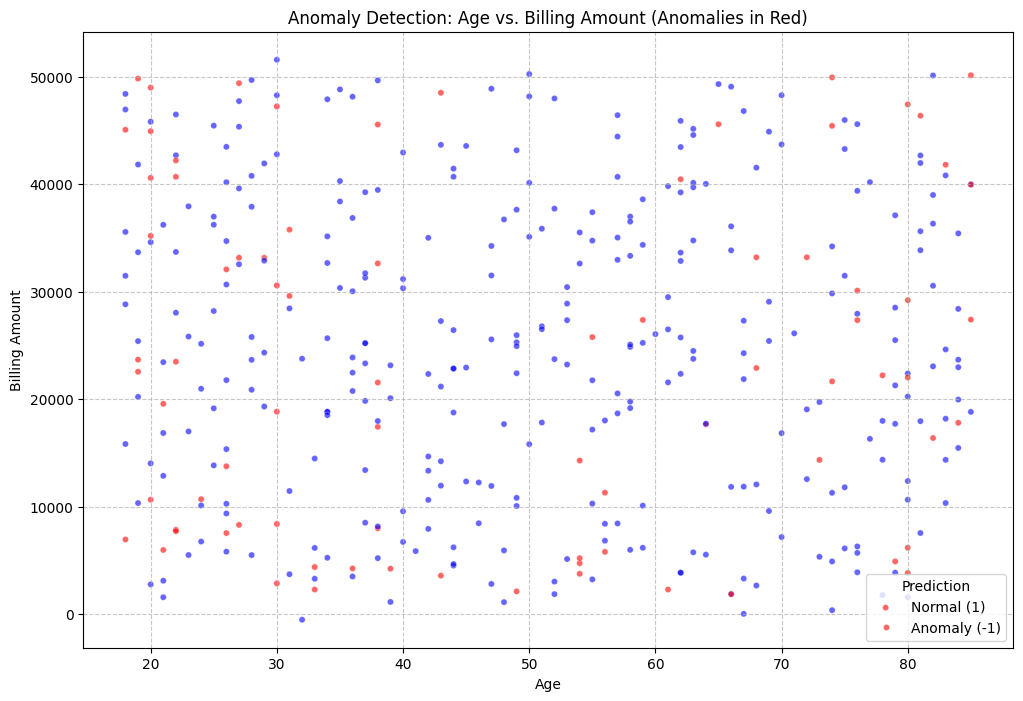

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of two numerical features, e.g., 'Age' and 'Billing Amount'
# Color-code points based on anomaly prediction
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Age',
    y='Billing Amount',
    hue='anomaly_prediction',
    palette={1: 'blue', -1: 'red'},
    data=df_final,
    alpha=0.6,
    s=20 # Adjust point size for better visibility
)
plt.title('Anomaly Detection: Age vs. Billing Amount (Anomalies in Red)')
plt.xlabel('Age')
plt.ylabel('Billing Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Prediction', labels=['Normal (1)', 'Anomaly (-1)'])
plt.show()

DataFrame head with custom anomaly predictions (threshold > 0.08):


,anomaly_score,anomaly_prediction,custom_anomaly_prediction
0,-0.028091,-1,1
1,0.058005,1,1
2,0.046377,1,1
3,0.010584,1,1
4,0.020752,1,1



Number of custom anomalies detected: 2
Percentage of custom anomalies detected: 0.50%


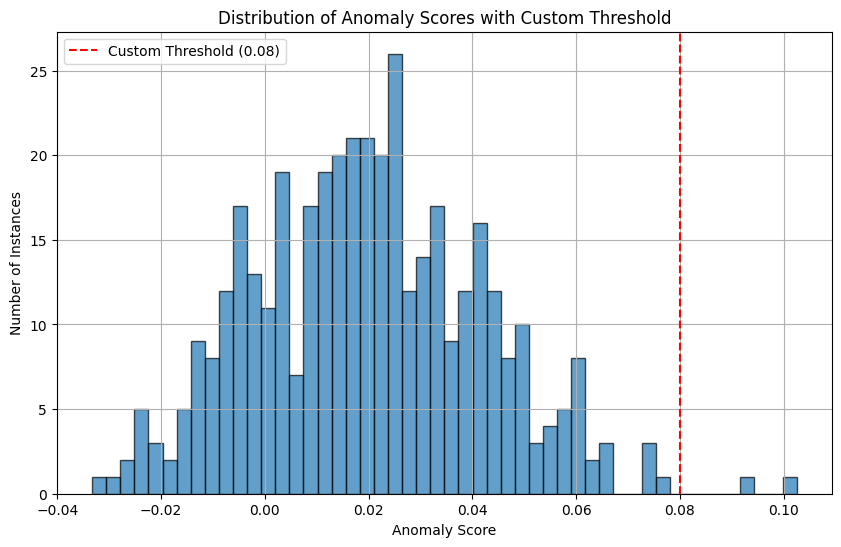

In [51]:
# Define a custom threshold for anomaly scores
custom_anomaly_threshold = 0.08

# Create a new column for custom anomaly prediction
df_final['custom_anomaly_prediction'] = df_final['anomaly_score'].apply(lambda x: -1 if x > custom_anomaly_threshold else 1)

# Display the first few rows with the new custom prediction
print(f"DataFrame head with custom anomaly predictions (threshold > {custom_anomaly_threshold}):")
display(df_final[['anomaly_score', 'anomaly_prediction', 'custom_anomaly_prediction']].head())

# Display the number of anomalies detected with the custom threshold
num_custom_anomalies = df_final[df_final['custom_anomaly_prediction'] == -1].shape[0]
print(f"\nNumber of custom anomalies detected: {num_custom_anomalies}")
print(f"Percentage of custom anomalies detected: {(num_custom_anomalies / len(df_final) * 100):.2f}%")

# Visualize the distribution again with the custom threshold marked
plt.figure(figsize=(10, 6))
plt.hist(df_final['anomaly_score'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=custom_anomaly_threshold, color='red', linestyle='--', label=f'Custom Threshold ({custom_anomaly_threshold:.2f})')
plt.title('Distribution of Anomaly Scores with Custom Threshold')
plt.xlabel('Anomaly Score')
plt.ylabel('Number of Instances')
plt.grid(True)
plt.legend()
plt.show()